# Inverse Constant (Sec 4.4)

Recover a known simulation parameter from observed trajectory data using adjoint
differentiation through the ODE solver. Here we recover the Earth's gravitational
parameter (GM) starting from an initial guess of 0.5x the true value.

The same approach applies to Moon mass, Sun mass, and J2 (Tab 7 in paper).
Achievable precision scales with integrator step size; finer stepping yields
tighter convergence.

In [1]:
import base
import optax
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jax import grad, jit
from physics import G, earth_mass, earth_radius, compute_third_body_acceleration
from utils import sample_moonsun_cubic, load_trajectory
from integrator import solve

jax.config.update('jax_enable_x64', True)

In [2]:
TRUE_MU = 3.986004418e14

def acceleration_model(position, time, factor, conditions):
    """Gravity (scaled by factor) + J2 + luni-solar perturbations."""
    MU = TRUE_MU * factor
    r = jnp.linalg.norm(position)
    grav_acc = -MU * position / (r ** 3)

    x, y, z = position
    r2, z2 = r * r, z * z
    J2 = 1.08263e-3
    j2_factor = 1.5 * J2 * (G * earth_mass * earth_radius**2) / (r**5)
    j2_acc = jnp.array([
        -x * (1.0 - 5.0 * z2 / r2) * j2_factor,
        -y * (1.0 - 5.0 * z2 / r2) * j2_factor,
        -z * (3.0 - 5.0 * z2 / r2) * j2_factor,
    ])

    moon_positions, sun_positions, reference_times = conditions
    moon_pos = sample_moonsun_cubic(time, moon_positions, reference_times)
    sun_pos = sample_moonsun_cubic(time, sun_positions, reference_times)
    moon3bp = compute_third_body_acceleration(position, moon_pos, 7.346e22)
    sun3bp = compute_third_body_acceleration(position, sun_pos, 1.989e30)

    return grav_acc + j2_acc + moon3bp + sun3bp

In [3]:
trajectory = load_trajectory(base.drive_path + 'trajectories/gps08.csv', limit=None)
conditions = (trajectory.moon, trajectory.sun, trajectory.time)

step_size = 5
prop_hours = 12
step_count = int(prop_hours * 3600 / step_size)
t0 = trajectory.time[0]
t1 = t0 + step_size * step_count
z0_flat = jnp.concatenate([trajectory.position[0], trajectory.velocity[0]])
z0_2d = jnp.array([trajectory.position[0], trajectory.velocity[0]])

print(f'{prop_hours}h propagation, dt={step_size}s, {step_count} steps')

def state_derivative(state, time, conditions):
    return jnp.concatenate([state[3:], acceleration_model(state[:3], time, 1.0, conditions)])

_, ref_states = solve(z0_flat, t0, t1, state_derivative, conditions, step_count=step_count)
ref_final_pos = ref_states[-1, :3]
print(f'Reference endpoint: {ref_final_pos}')

12h propagation, dt=5s, 8640 steps


Reference endpoint: [-26480428.67396271   1900971.47624005   2834506.04018396]


In [4]:
def ode_grad(ode, loss, z0, t0, t1, parameters, *args, step_count=11524):
    """Compute gradient of loss w.r.t. parameters via adjoint method."""
    def augmented_ode(state, t, parameters, *args):
        z, a = state[0], state[1]
        q0, _, q2, *_ = jax.vjp(ode, z, t, parameters, *args)[1](a)
        return (
            ode(z, t, parameters, *args),
            jax.tree.map(lambda u: -u, q0),
            jax.tree.map(lambda u: -u, q2),
        )

    z1 = solve(z0, t0, t1, ode, parameters, *args)[1][-1]
    init = (z1, grad(loss)(z1), jax.tree.map(jnp.zeros_like, parameters))
    aug_sol = solve(init, t1, t0, augmented_ode, parameters, *args)[1]
    return jax.tree.map(lambda u: u[-1], aug_sol)[2]

In [5]:
def orbit_ode(z, t, param, *args):
    return jnp.array([z[1], acceleration_model(z[0], t, param, args[0])])

def loss(state):
    return jnp.linalg.norm(state[0] - ref_final_pos) ** 2

j_grad = jit(jax.tree_util.Partial(ode_grad, orbit_ode, loss))
j_loss = jit(lambda p: loss(solve(z0_2d, t0, t1, orbit_ode, p, conditions, step_count)[1][-1]))

def compute_grad(param):
    return j_grad(z0_2d, t0, t1, param, conditions, step_count)

In [6]:
param = 0.5
optimizer = optax.adam(learning_rate=0.01)
opt_state = optimizer.init(param)

losses, params = [], []

for i in range(500):
    g = compute_grad(param)
    updates, opt_state = optimizer.update(g, opt_state)
    param = optax.apply_updates(param, updates)
    l = j_loss(param)
    losses.append(float(l))
    params.append(float(param))
    if i % 50 == 0:
        print(f'iter {i:4d}  factor={param:.12f}  rel_error={abs(param-1):.3e}  loss={l:.3e}')

print(f'\nFinal: factor={param:.15f}  rel_error={abs(param-1):.3e}')
print(f'Recovered GM = {TRUE_MU * param:.6e}  (true = {TRUE_MU:.6e})')

iter    0  factor=0.510000000000  rel_error=4.900e-01  loss=1.246e+16


iter   50  factor=1.007247940833  rel_error=7.248e-03  loss=5.540e+12


iter  100  factor=0.994444934057  rel_error=5.555e-03  loss=3.414e+12


iter  150  factor=0.999913455360  rel_error=8.654e-05  loss=5.614e+08


iter  200  factor=0.999991941600  rel_error=8.058e-06  loss=4.698e+06


...

iter  300  factor=0.999985260764  rel_error=1.474e-05  loss=1.114e+03


iter  350  factor=0.999985348012  rel_error=1.465e-05  loss=2.146e+01


iter  400  factor=0.999985361771  rel_error=1.464e-05  loss=2.310e-02


iter  450  factor=0.999985362144  rel_error=1.464e-05  loss=1.391e-02



Final: factor=0.999985362070669  rel_error=1.464e-05
Recovered GM = 3.985946e+14  (true = 3.986004e+14)


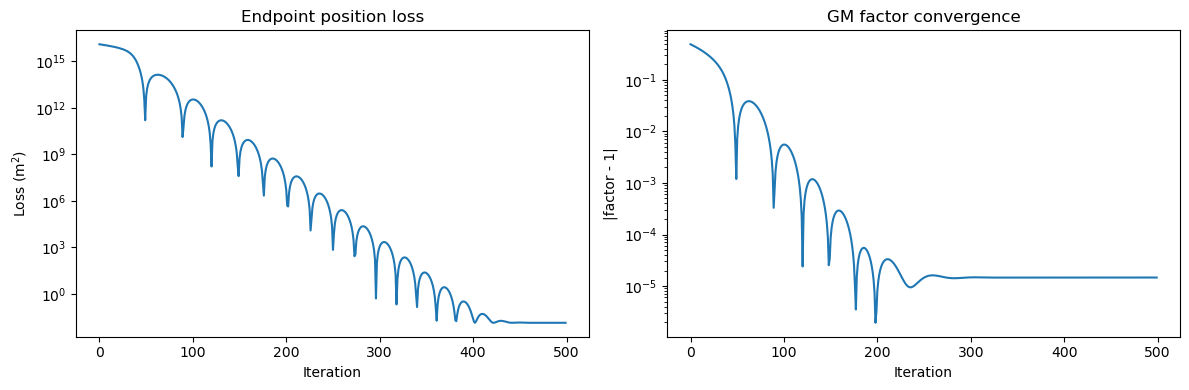

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses)
ax1.set_yscale('log')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss (m$^2$)')
ax1.set_title('Endpoint position loss')

ax2.plot(np.abs(np.array(params) - 1.0))
ax2.set_yscale('log')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('|factor - 1|')
ax2.set_title('GM factor convergence')

plt.tight_layout()
plt.show()